In [ ]:
import pandas as pd
import matplotlib .
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px 
import seaborn as sns

# %matplotlib inline - to ensure charts created are shown directly and not as pop ups

titanic_clean = pd.read_csv('titanic_clean.csv')

In [2]:
fig =px.histogram(
    titanic_clean,
    x='Age',
    marginal='box',
    color_discrete_sequence= ['red'],
    nbins = 45,
    title='DISTRIBUTION OF AGE'
)

fig.update_layout(bargap=0.1)
fig.show()

In [3]:
fig =px.histogram(
    titanic_clean,
    x='Fare',
    marginal='box',
    color_discrete_sequence= ['blue'],
    nbins = 45,
    title='DISTRIBUTION OF FARE'
)

fig.update_layout(bargap=0.1)
fig.show()

In [4]:
fig =px.histogram(
    titanic_clean,
    x='Age',
    marginal='box',
    color ='Pclass',
    color_discrete_sequence= ['green', 'orange','purple'],
    nbins = 35,
    title='DISTRIBUTION OF FARE CONSIDERING CLASS'
)

fig.update_layout(bargap=0.1)
fig.show()

In [5]:
fig =px.histogram(
    titanic_clean,
    x='Pclass',
    marginal='box',
    color ='Sex',
    color_discrete_sequence= ['green', 'orange','purple'],
    nbins = 35,
    title='DISTRIBUTION OF PCLASS CONSIDERING SEX'
)

fig.update_layout(bargap=0.1)
fig.show()

In [6]:
# VISUALIZING THE RELATIONSHIP BETWEEN AGE AND THE FARE

fig =px.scatter(
    titanic_clean,
    x='Age',
    y='Fare',
    color ='Sex',
    opacity=1.0,
    hover_data=['Sex'],
    title=' GRAPH OF FARE AGAINST AGE'
)

fig.update_layout(bargap=0.1)
fig.show()

In [7]:
# VISUALIZING THE RELATIONSHIP BETWEEN PCLASS AND THE FARE

fig =px.violin(
    titanic_clean,
    x='Pclass',
    y='Fare',
    title=' GRAPH OF PCLASS AGAINST FARE'
)

fig.update_layout(bargap=0.2)
fig.show()

In [8]:
# VISUALIZING THE RELATIONSHIP BETWEEN SIBSP AND THE FARE

fig =px.violin(
    titanic_clean,
    x='SibSp',
    y='Fare',
    title=' GRAPH OF SibSp AGAINST FARE'
)

fig.update_layout(bargap=0.2)
fig.show()

In [9]:
# CHECKING THE CORRELATION BETWEEN COLUMNS
# CORRELATION = R
# -1<=R<=1   -> the higher the value the higher the relationship

print("THE CORRELATION BETWEEN FARE AND AGE IS: ",titanic_clean.Fare.corr(titanic_clean.Age))
print("THE CORRELATION BETWEEN FARE AND PCLASS IS: ",titanic_clean.Fare.corr(titanic_clean.Pclass))

Sex_values = {'male': 1, 'female': 0}
Sex_numeric= titanic_clean.Sex.map(Sex_values)
print("THE CORRELATION BETWEEN FARE AND SEX IS: ",titanic_clean.Fare.corr(Sex_numeric),"\n")

Embarked_values = {'Q': 1, 'S': 0, 'C': 0.5}
Embarked_numeric= titanic_clean.Embarked.map(Embarked_values)
print("THE CORRELATION BETWEEN FARE AND EMBARKED IS: ",titanic_clean.Fare.corr(Embarked_numeric),"\n")
print("THE CORRELATION BETWEEN FARE AND  PARCH IS: ",titanic_clean.Fare.corr(titanic_clean.Parch))

print("THE CORRELATION BETWEEN FARE AND  SIBSP IS: ",titanic_clean.Fare.corr(titanic_clean.SibSp), "\n")

print("AGE, SIBSP AND PARCH HAVE  HIGHER CORRELATIONS HENCE WILL BE USED!")



THE CORRELATION BETWEEN FARE AND AGE IS:  0.1966216277484821
THE CORRELATION BETWEEN FARE AND PCLASS IS:  -0.67909175927058
THE CORRELATION BETWEEN FARE AND SEX IS:  -0.16971468846378987 

THE CORRELATION BETWEEN FARE AND EMBARKED IS:  -0.12696295319302625 

THE CORRELATION BETWEEN FARE AND  PARCH IS:  0.32443101426229914
THE CORRELATION BETWEEN FARE AND  SIBSP IS:  0.29182924769694524 

AGE, SIBSP AND PARCH HAVE  HIGHER CORRELATIONS HENCE WILL BE USED!


In [10]:
print(titanic_clean['Parch'].unique())
print(titanic_clean['SibSp'].unique())


[0 1 2 4 6 5 3]
[0 1 2 4 5 3]


In [ ]:
# TO COMPUTE ALL THE CORRELATIONS AT ONCE WHEN ALL COLUMNS ARE NUMERICAL
#matrix=titanic_clean.describe().corr()
# A correlation matrix can be created using a heatmap. HERE IS AN EXAMPLE

#sns.heatmap(matrix, cmap='Reds', annot=True)
#plt.title("CORRELATION MATRIX")



THESE ARE THE MODEL PREDICTED FARE CHARGES: 

 0      10.8
1      13.4
2       9.4
3       8.4
4       6.8
       ... 
335     9.6
336     9.4
337    11.6
338     9.4
339     9.4
Name: Age, Length: 340, dtype: float64
THESE ARE THE ACTUAL FARE CHARGES: 

 0       7.8292
1       7.0000
2       8.6625
3      12.2875
4       9.2250
        ...   
335     7.7750
336     8.0500
337     7.2500
338     8.0500
339    22.3583
Name: Fare, Length: 340, dtype: float64


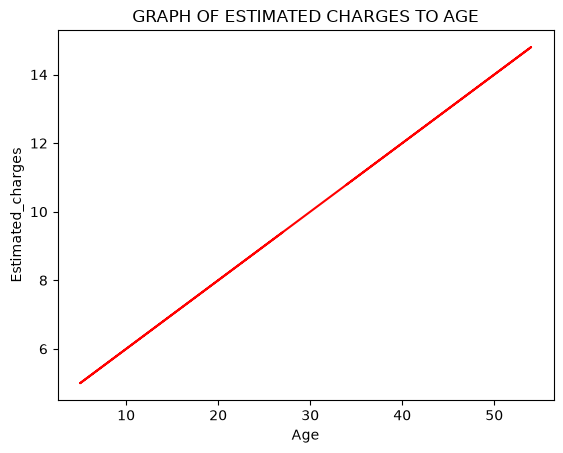

In [12]:
# REGRESSION FORMULAE FOR FARE VS AGE
# Y = WX +B  -> Y = Age*W + Fare intercept
# Y -> Fare,  W -> slope,  B-> Fare intercept

def estimate_fare(ages,W,B):
     return W *ages + B
W=0.2
B=4
ages = titanic_clean.Age
estimated_charges = estimate_fare(ages,W,B)

#PLOT THE RESULT
plt.plot(ages, estimated_charges,'r-')
plt.xlabel('Age')
plt.ylabel('Estimated_charges')
plt.title('GRAPH OF ESTIMATED CHARGES TO AGE')

estimated_charges = estimate_fare(ages,W,B)
print("THESE ARE THE MODEL PREDICTED FARE CHARGES: \n\n",estimated_charges)

print("THESE ARE THE ACTUAL FARE CHARGES: \n\n",titanic_clean.Fare)



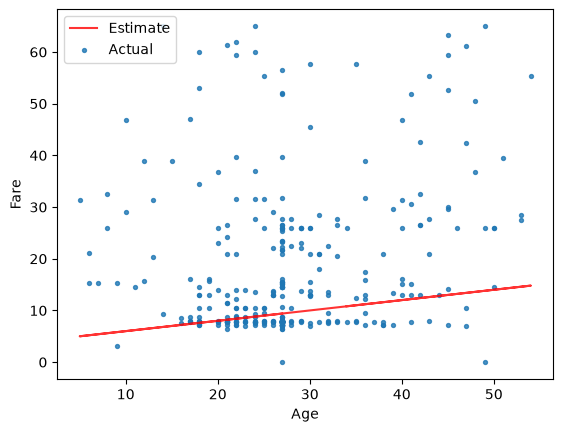

In [13]:
# WE CAN OVERLAY THIS LINE ON THE ACTUAL DATA TO SEE HOW BEST IT FITS
target = titanic_clean.Fare
plt.plot(ages, estimated_charges, 'r', alpha=0.8)

plt.scatter(ages, target,s=8,  alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(['Estimate', 'Actual']);



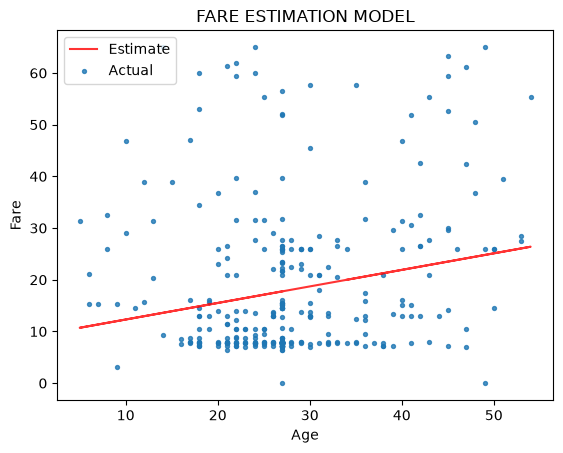

In [14]:
# WE CAN OVERLAY THIS LINE ON THE ACTUAL DATA TO SEE HOW BEST IT FITS using changing parameters W and B

def try_parameters(W, B):
    ages= titanic_clean.Age
    target = titanic_clean.Fare
    estimated_charges = estimate_fare(ages, W, B)
    
    plt.plot(ages, estimated_charges, 'r', alpha=0.8)
    plt.scatter(ages, target,s=8,  alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Fare')
    plt.legend(['Estimate', 'Actual']);
    plt.title('FARE ESTIMATION MODEL')
    
    
try_parameters(0.32,9.11)




#   LINEAR REGRESSION USING A SINGLE FEATURE (AGE)

# LOSS / COST FUNCTION -> TO MEASURE NUMERICALLY HOW WELL THE LINE FITS THE POINTS
 This is done by comparing the model's predictions with the actual targets to get a single number -> root mean square error(RMSE)

# WHY WE NEED THIS:
 Visually inspecting the plot only gives a rough idea of fit.
 A cost function gives us an exact number so we can compare
 different values of W and B objectively, and later find the
 combination that minimizes this error (best fit line).

# RMSE FORMULA:
   RMSE = sqrt( (1/n) * sum( (actual_i - predicted_i)^2 ) )

# STEP-BY-STEP:
 1. error_i        = actual_i - predicted_i        (residual for each point)
 2. squared_error_i = error_i ** 2                  (penalize larger errors more, remove sign)
 3. mean_squared_error = mean(squared_error_i)      (average over all n points)
 4. RMSE = sqrt(mean_squared_error)                 (bring units back to original scale, e.g. Fare)

# LOWER RMSE -> BETTER FIT (predictions closer to actual values)
# HIGHER RMSE -> WORSE FIT (predictions far from actual values)




In [ ]:
# DEMONSTRATION ON FINDING LOSS

def rmse (targets, predictions):
    return np.sqrt(np.mean(np.square(targets-predictions)))

W = 0.32
B = 9.11
estimated_charges = estimate_fare(ages, W, B)
targets = titanic_clean['Fare']
predictions = estimated_charges

print("THE RMSE IS: ",rmse(targets, predictions))
print("COMPARE IT TO EITHER THE MEAN, MEDIAN, MIN AND MAX of the target")


THE RMSE IS:  14.005254961454751
COMPARE IT TO EITHER THE MEAN, MEDIAN, MIN AND MAX of the target


# OPTIMIZER

There needs to be a strategy to modify the slope and the interface to improve the fit of the line to the data
There are two main methods: 
     1. Ordinary least squares -> for small data sets
     2. Stochastic gradient descent -> for larger datasets

This can be done using the scikit-learn library

In [16]:
from sklearn.linear_model import LinearRegression

# CREATE A NEW MODEL OBJECT
model = LinearRegression()

# THE FEATURES (INPUTS) MUST BE A 2D ARRAY WHILE THE TARGET CAN BE EITHER 1 OR 2D

inputs = titanic_clean[['Age']]
targets = titanic_clean.Fare

# FIT THE MODEL INTO THE DATA
model.fit(inputs, targets)

# TRY PREDICTING THE FARE FOR DIFFERENT AGES
model.predict(
    np.array([[23], [37], [61]])
)
# NOW COMPUTE PREDICTIONS FOR THE ENTIRE SET OF INPUTS
predictions = model.predict(inputs)
predictions






c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([19.81959431, 23.91478568, 17.61449127, 16.03941767, 13.5192999 ,
       18.55953543, 17.29947655, 14.77935878, 15.72440295, 17.61449127,
       23.59977096, 23.91478568, 16.66944711, 20.13460903, 15.72440295,
       17.61449127, 23.28475624, 11.9442263 , 17.61449127, 15.72440295,
       24.85982984, 16.03941767, 16.03941767, 22.02469736, 17.61449127,
       24.85982984, 16.66944711, 19.50457959, 17.61449127, 18.55953543,
       14.77935878, 17.61449127, 15.72440295, 16.98446183, 17.61449127,
       21.39466792, 17.61449127, 22.02469736, 18.55953543, 23.28475624,
       16.98446183, 23.28475624, 17.61449127, 20.44962375, 16.66944711,
       17.61449127, 15.40938823, 17.61449127, 12.25924102, 20.13460903,
       16.98446183, 17.61449127, 14.46434406, 19.18956487, 14.77935878,
       16.03941767, 17.61449127, 14.77935878, 23.91478568, 18.87455015,
       16.66944711, 15.72440295, 18.24452071, 17.92950599, 17.61449127,
       18.55953543, 16.66944711, 10.99918214, 24.54481512, 17.61

In [17]:
# NOW YOU CAN GET THE LOSS
print("THE LOSS IS: ",rmse(targets, predictions))

#YOU CAN ALSO GET THE SLOPE (W)
print("THE REGRESSION SLOPE (W) IS: ", model.coef_)

#YOU CAN ALSO GET THE INTERCEPT (B)
print("THE REGRESSION INTERCEPT (B) IS: ", model.intercept_)

THE LOSS IS:  14.004492036902082
THE REGRESSION SLOPE (W) IS:  [0.31501472]
THE REGRESSION INTERCEPT (B) IS:  9.109093813779506


# LINEAR REGRESSION USING MULTIPLE FEATURES

Given the correlation of each of the remaining features were previously computed, the onlt columns that have a relationship with fare are:
   Age
   SibSp
   Parch

These will be the features used to create the model now

In [18]:
print("The SibSp correlation is: ",titanic_clean.Fare.corr(titanic_clean.SibSp))
print("The Parch correlation is: ",titanic_clean.Fare.corr(titanic_clean.Parch))

inputs = titanic_clean[['Age', 'SibSp', 'Parch']]
targets = titanic_clean['Fare']


model_two = LinearRegression()
model_two.fit(inputs, targets)
predictions_two = model_two.predict(inputs)

# NOW YOU CAN GET THE LOSS
print("THE LOSS IS: ",rmse(targets, predictions_two))

#YOU CAN ALSO GET THE SLOPE (W)
print("THE REGRESSION SLOPE (W) IS: ", model_two.coef_)

#YOU CAN ALSO GET THE INTERCEPT (B)
print("THE REGRESSION INTERCEPT (B) IS: ", model_two.intercept_)


The SibSp correlation is:  0.29182924769694524
The Parch correlation is:  0.32443101426229914
THE LOSS IS:  12.750935733777023
THE REGRESSION SLOPE (W) IS:  [0.39208375 4.94056599 4.86163549]
THE REGRESSION INTERCEPT (B) IS:  3.8823731701555495
